In [13]:
import pandas as pd

day_0_prices = pd.read_csv("../../data/round_1/prices_round_1_day_0.csv", sep=";")
day_1_prices = pd.read_csv("../../data/round_1/prices_round_1_day_-1.csv", sep=";")
day_2_prices = pd.read_csv("../../data/round_1/prices_round_1_day_-2.csv", sep=";")

day_0_trades = pd.read_csv("../../data/round_1/trades_round_1_day_0.csv", sep=";")
day_1_trades = pd.read_csv("../../data/round_1/trades_round_1_day_-1.csv", sep=";")
day_2_trades = pd.read_csv("../../data/round_1/trades_round_1_day_-2.csv", sep=";")

In [14]:
day_0_prices["product"].value_counts()

product
ASH_COATED_OSMIUM       10000
INTARIAN_PEPPER_ROOT    10000
Name: count, dtype: int64

In [15]:
day_0_ash_prices = day_0_prices[day_0_prices["product"] == "ASH_COATED_OSMIUM"].copy()
day_1_ash_prices = day_1_prices[day_1_prices["product"] == "ASH_COATED_OSMIUM"].copy()
day_2_ash_prices = day_2_prices[day_2_prices["product"] == "ASH_COATED_OSMIUM"].copy()

day_0_root_prices = day_0_prices[day_0_prices["product"] == "INTARIAN_PEPPER_ROOT"].copy()
day_1_root_prices = day_1_prices[day_1_prices["product"] == "INTARIAN_PEPPER_ROOT"].copy()
day_2_root_prices = day_2_prices[day_2_prices["product"] == "INTARIAN_PEPPER_ROOT"].copy()

ash_prices = pd.concat([day_2_ash_prices, day_1_ash_prices, day_0_ash_prices])
root_prices = pd.concat([day_2_root_prices, day_1_root_prices, day_0_root_prices])

#tom_trades["global_time"] = tom_trades["day"] * 1_000_000 + tom_trades["timestamp"]
ash_prices["global_time"] = ash_prices["day"] * 1_000_000 + ash_prices["timestamp"]

#eme_trades["global_time"] = eme_trades["day"] * 1_000_000 + eme_trades["timestamp"]
root_prices["global_time"] = root_prices["day"] * 1_000_000 + root_prices["timestamp"]

In [16]:
ash_prices

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_time
1,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0,-2000000
3,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0,-1999900
5,-2,200,ASH_COATED_OSMIUM,9992.0,15.0,9989.0,30.0,NaN,NaN,10008.0,15.0,10010.0,30.0,NaN,NaN,10000.0,0.0,-1999800
6,-2,300,ASH_COATED_OSMIUM,9992.0,13.0,9989.0,26.0,NaN,NaN,10008.0,13.0,10010.0,26.0,NaN,NaN,10000.0,0.0,-1999700
8,-2,400,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10010.0,20.0,NaN,NaN,10000.0,0.0,-1999600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19990,0,999500,ASH_COATED_OSMIUM,10000.0,13.0,9997.0,28.0,NaN,NaN,10018.0,28.0,NaN,NaN,NaN,NaN,10009.0,0.0,999500
19993,0,999600,ASH_COATED_OSMIUM,10000.0,14.0,9997.0,27.0,NaN,NaN,10016.0,14.0,10018.0,27.0,NaN,NaN,10008.0,0.0,999600
19994,0,999700,ASH_COATED_OSMIUM,10000.0,11.0,9997.0,24.0,NaN,NaN,10016.0,11.0,10018.0,24.0,NaN,NaN,10008.0,0.0,999700
19997,0,999800,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10018.0,27.0,NaN,NaN,NaN,NaN,10018.0,0.0,999800


In [17]:
ash_prices["total_bid_volume"] = (ash_prices["bid_volume_1"].fillna(0) + ash_prices["bid_volume_2"].fillna(0) + ash_prices["bid_volume_3"].fillna(0))
ash_prices["total_ask_volume"] = (ash_prices["ask_volume_1"].fillna(0) + ash_prices["ask_volume_2"].fillna(0) + ash_prices["ask_volume_3"].fillna(0))
ash_prices["order_imbalance"] = (ash_prices["total_bid_volume"] - ash_prices["total_ask_volume"]) / (ash_prices["total_bid_volume"] + ash_prices["total_ask_volume"])
ash_prices["spread"] = ash_prices["ask_price_1"] - ash_prices["bid_price_1"]

In [18]:
ash_prices.head(10)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_time,total_bid_volume,total_ask_volume,order_imbalance,spread
1,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,...,NaN,NaN,NaN,10010.0,0.0,-2000000,0.0,25.0,-1.000000,NaN
3,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,...,20.0,NaN,NaN,10000.0,0.0,-1999900,15.0,35.0,-0.400000,16.0
5,-2,200,ASH_COATED_OSMIUM,9992.0,15.0,9989.0,30.0,NaN,NaN,10008.0,...,30.0,NaN,NaN,10000.0,0.0,-1999800,45.0,45.0,0.000000,16.0
6,-2,300,ASH_COATED_OSMIUM,9992.0,13.0,9989.0,26.0,NaN,NaN,10008.0,...,26.0,NaN,NaN,10000.0,0.0,-1999700,39.0,39.0,0.000000,16.0
8,-2,400,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,...,20.0,NaN,NaN,10000.0,0.0,-1999600,15.0,35.0,-0.400000,16.0
11,-2,500,ASH_COATED_OSMIUM,9992.0,13.0,9989.0,30.0,NaN,NaN,10008.0,...,30.0,NaN,NaN,10000.0,0.0,-1999500,43.0,43.0,0.000000,16.0
12,-2,600,ASH_COATED_OSMIUM,9989.0,30.0,NaN,NaN,NaN,NaN,10010.0,...,NaN,NaN,NaN,9999.5,0.0,-1999400,30.0,30.0,0.000000,21.0
14,-2,700,ASH_COATED_OSMIUM,9990.0,27.0,NaN,NaN,NaN,NaN,10011.0,...,NaN,NaN,NaN,10000.5,0.0,-1999300,27.0,27.0,0.000000,21.0
16,-2,800,ASH_COATED_OSMIUM,9993.0,15.0,NaN,NaN,NaN,NaN,10011.0,...,NaN,NaN,NaN,10002.0,0.0,-1999200,15.0,21.0,-0.166667,18.0
19,-2,900,ASH_COATED_OSMIUM,9993.0,13.0,9990.0,30.0,NaN,NaN,9998.0,...,13.0,10011.0,30.0,9995.5,0.0,-1999100,43.0,51.0,-0.085106,5.0


In [19]:
ash_prices["mid_price"] = (ash_prices["ask_price_1"] + ash_prices["bid_price_1"])/2

In [20]:
ash_prices["mid_price"].mean()

np.float64(10000.209123137029)

In [21]:
ash_prices["spread"].mean()

np.float64(16.175227897554624)

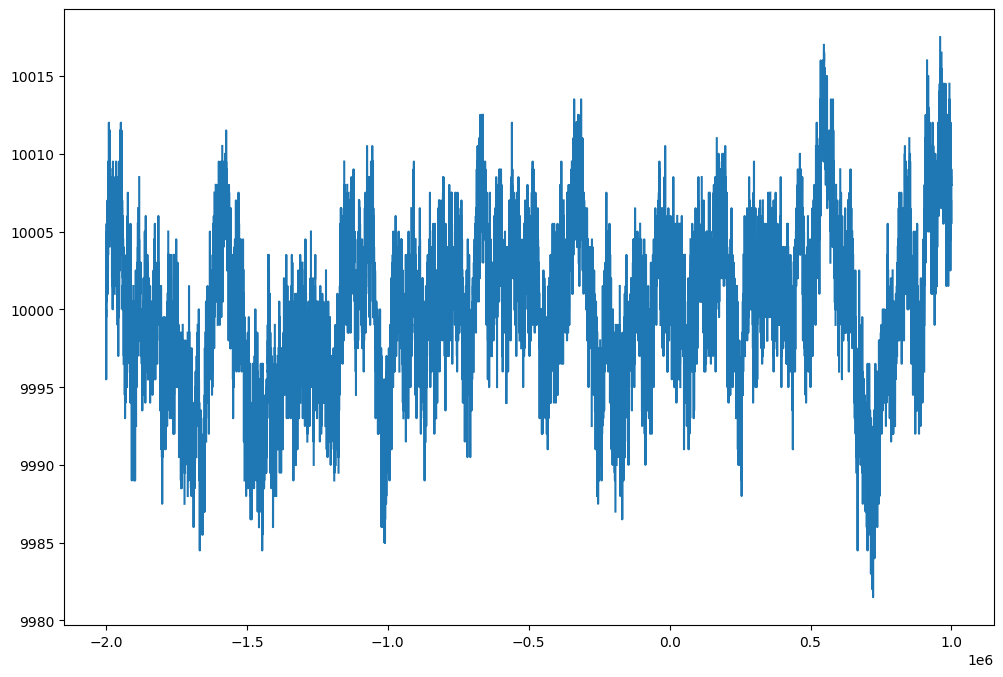

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.plot(ash_prices["global_time"], ash_prices["mid_price"])

In [27]:
ash_prices["mid_price"].std()

np.float64(4.858190724566338)